# FitzHugh

{func}`.FitzHugh` - the {cite:t}`FitzHugh1961` model without external stimulus.

The FitzHugh model is commonly used to test ODE software {cite:p}`Ramsay2007` {cite}`Girolami2011`, the model itself describes the excitation state of a neuron membrane as an excitation spike passes. PyGOM also includes other functions which are commonly used to test numerical integrators such as:
{func}`.vanDerPol` - the Van der Pol oscillator {cite}`vanderPol1926` and
{func}`.Robertson` - the Robertson reaction {cite}`Robertson1966`.
The FitzHugh model equations are as follows:

$$\begin{aligned}
\frac{\mathrm{d} V}{\mathrm{d} t} &=  c ( V - \frac{V^{3}}{3} + R) \\
\frac{\mathrm{d} R}{\mathrm{d} t} &= -\frac{1}{c}(V - a + bR).
\end{aligned}$$

We solve for the deterministic time evolution of the system:

In [8]:
import numpy as np
from pygom import common_models
import matplotlib.pyplot as plt

model = common_models.FitzHugh(
    {
        'a':0.2,
        'b':0.2,
        'c':3.0
    }
)

t = np.linspace(0, 20, 100)
x0 = [1.0, -1.0]
model.initial_values = (x0, t[0])

solution = model.solve_deterministic(t)

Plotting the function reveals frequent sharp transitions, which makes it an appropriate system to test ODE solving methods.

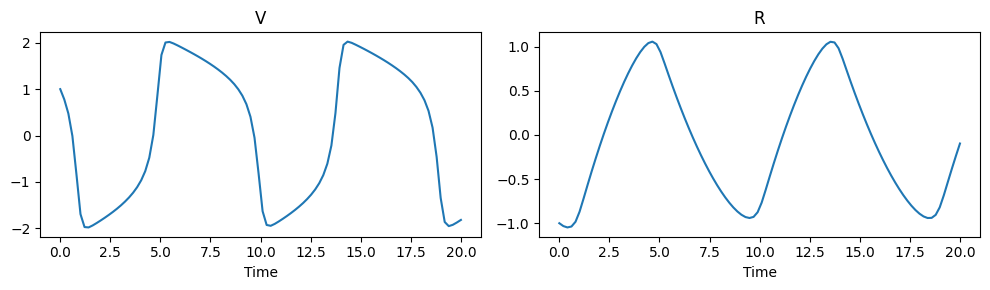

In [9]:
state_names = model.state_list
n_state = len(state_names)

fig, axes = plt.subplots(1, n_state, figsize=(10, 3))

for i in range(n_state):
    axes[i].plot(t, solution[0].result.y[:, i])
    axes[i].set_title(state_names[i])
    axes[i].set_xlabel("Time")

plt.tight_layout()
plt.show()